# 07.03 — Peak-Risk Distribution

Review class balance using the leakage-safe walk-forward diagnostic Peak labels.

In [1]:
# Import libraries
from pathlib import Path
import sys

In [2]:
# Define the root directory of the project
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'target_definition.yaml'
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/target_definition.yaml')

In [3]:
# Import module to manage the Target Definition process
from src.ontario_peak_risk.target_definition.common import (
    load_target_config,
    load_feature_dataset,
    ensure_directories,
)

In [4]:
# Configure the Target Definition process
CONFIG, _ = load_target_config(CONFIG_PATH)
OUTPUT_DIR, REPORTS_DIR, DOCS_DIR = ensure_directories(CONFIG, PROJECT_ROOT)
feature_dataset = load_feature_dataset(CONFIG, PROJECT_ROOT)
feature_dataset.shape

(262944, 100)

In [ ]:
# Import module to build the Peak Risk Target matrix and generate reports
from src.ontario_peak_risk.target_definition.peak_risk_target import (
    build_walk_forward_peak_diagnostics,
    peak_distribution_reports,
)

In [6]:
# Build the Peak Risk Target matrix
PEAK_CFG = CONFIG['target_definition']['peak_risk']
peak_labels, peak_thresholds = build_walk_forward_peak_diagnostics(
    feature_dataset,
    percentile=PEAK_CFG['percentile_threshold'],
    target_column=PEAK_CFG['target_column'],
    grouping_columns=PEAK_CFG['grouping_columns'],
    time_column=PEAK_CFG['diagnostic_time_column'],
    minimum_training_years=PEAK_CFG['minimum_training_years'],
)
distributions = peak_distribution_reports(peak_labels)

In [7]:
# Display the overall distribution of peak risk targets
distributions['overall']

,observations,peak_hours,peak_rate_pct
0,210384,13784,6.551829


In [8]:
# Display the distribution of peak risk targets by FSA
distributions['by_fsa']

,fsa,observations,peak_hours,peak_rate_pct
0,L4T,35064,1162,3.31394
1,M5R,35064,1236,3.524983
2,M5S,35064,1120,3.194159
3,M6G,35064,1978,5.641113
4,M9R,35064,1502,4.283596
5,M9W,35064,6786,19.353183


In [9]:
# Display the distribution of peak risk targets by year
distributions['by_year']

,year,observations,peak_hours,peak_rate_pct
0,2022,52560,2272,4.322679
1,2023,52560,5757,10.953196
2,2024,52704,2110,4.003491
3,2025,52560,3645,6.934932


In [10]:
# Display the distribution of peak risk targets by season
distributions['by_season']

,season,observations,peak_hours,peak_rate_pct
0,Fall,52416,3586,6.841422
1,Spring,52992,3010,5.680103
2,Summer,52992,3080,5.812198
3,Winter,51984,4108,7.902432


In [13]:
# Calculate Peak Rate by FSA and evaluation year
peak_valid = peak_labels.loc[
    peak_labels["peak_risk_target"].notna()
].copy()

peak_rate_fsa_year = (
    peak_valid
    .groupby(
        ["fsa", "year"],
        observed=True,
    )
    .agg(
        observations=("peak_risk_target", "size"),
        peak_hours=("peak_risk_target", "sum"),
    )
    .reset_index()
)

peak_rate_fsa_year["peak_rate_pct"] = (
    peak_rate_fsa_year["peak_hours"]
    / peak_rate_fsa_year["observations"]
    * 100
)

peak_rate_fsa_year = (
    peak_rate_fsa_year
    .sort_values(["fsa", "year"])
    .reset_index(drop=True)
)

peak_rate_fsa_year

,fsa,year,observations,peak_hours,peak_rate_pct
0,L4T,2022,8760,370,4.223744
1,L4T,2023,8760,166,1.894977
2,L4T,2024,8784,245,2.789162
3,L4T,2025,8760,381,4.349315
4,M5R,2022,8760,317,3.618721
5,M5R,2023,8760,172,1.96347
6,M5R,2024,8784,147,1.673497
7,M5R,2025,8760,600,6.849315
8,M5S,2022,8760,357,4.075342
9,M5S,2023,8760,138,1.575342


In [14]:
# Display Peak Rate as an FSA × Year matrix
peak_rate_fsa_year_matrix = (
    peak_rate_fsa_year
    .pivot(
        index="fsa",
        columns="year",
        values="peak_rate_pct",
    )
)

peak_rate_fsa_year_matrix.round(2)

year,2022,2023,2024,2025
fsa,,,,
L4T,4.22,1.89,2.79,4.35
M5R,3.62,1.96,1.67,6.85
M5S,4.08,1.58,1.35,5.78
M6G,3.93,5.56,3.63,9.45
M9R,3.65,3.38,4.03,6.07
M9W,6.44,51.35,10.54,9.11


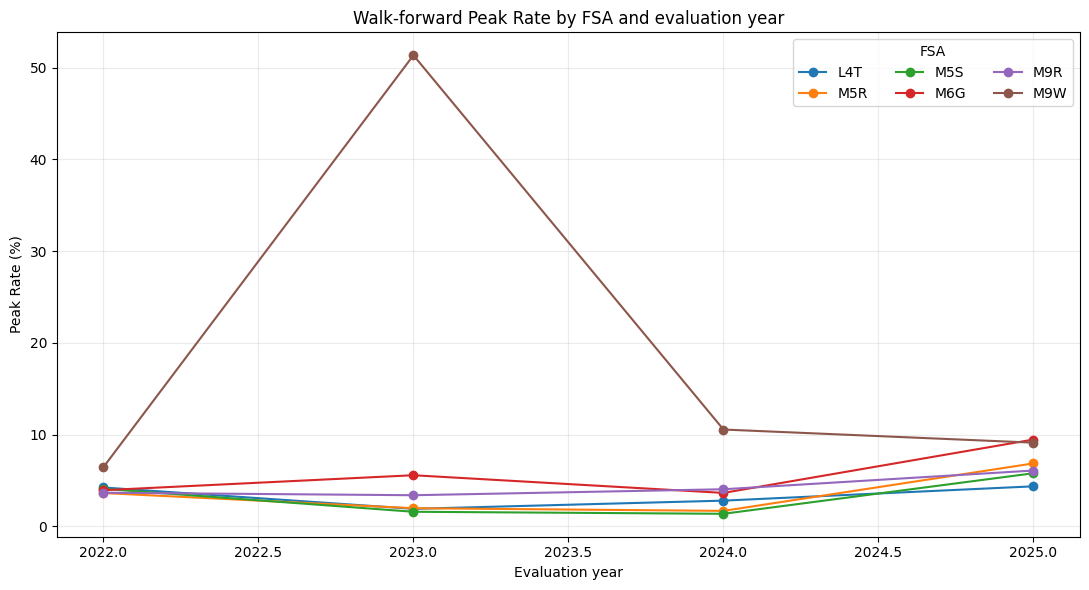

In [20]:
# Plot annual Peak Rate by FSA
import matplotlib.pyplot as plt

figure, axis = plt.subplots(
    figsize=(11, 6)
)

for fsa, group in peak_rate_fsa_year.groupby(
    "fsa",
    observed=True,
):
    group = group.sort_values("year")

    axis.plot(
        group["year"],
        group["peak_rate_pct"],
        marker="o",
        label=str(fsa),
    )

axis.set_xlabel("Evaluation year")
axis.set_ylabel("Peak Rate (%)")
axis.set_title(
    "Walk-forward Peak Rate by FSA and evaluation year"
)

axis.legend(
    title="FSA",
    ncol=3,
)

axis.grid(
    alpha=0.25
)

figure.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
    / "07_03_peak_rate_by_fsa_year.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

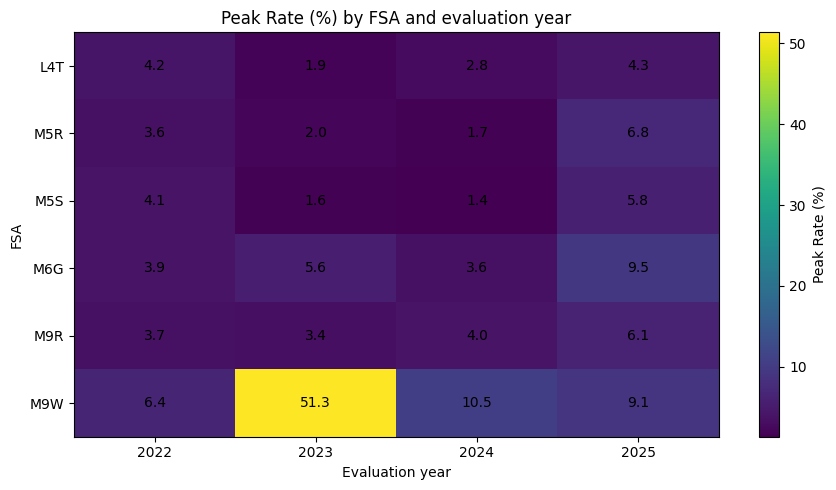

In [22]:
# Plot Peak Rate heatmap by FSA and year
import pandas as pd
heatmap_data = (
    peak_rate_fsa_year
    .pivot(
        index="fsa",
        columns="year",
        values="peak_rate_pct",
    )
)

figure, axis = plt.subplots(
    figsize=(9, 5)
)

image = axis.imshow(
    heatmap_data.astype(float).values,
    aspect="auto",
)

axis.set_xticks(
    range(len(heatmap_data.columns))
)

axis.set_xticklabels(
    heatmap_data.columns
)

axis.set_yticks(
    range(len(heatmap_data.index))
)

axis.set_yticklabels(
    heatmap_data.index
)

axis.set_xlabel("Evaluation year")
axis.set_ylabel("FSA")

axis.set_title(
    "Peak Rate (%) by FSA and evaluation year"
)

colorbar = figure.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    "Peak Rate (%)"
)

# Display values inside the heatmap
for row_index in range(
    len(heatmap_data.index)
):
    for column_index in range(
        len(heatmap_data.columns)
    ):
        value = heatmap_data.iloc[
            row_index,
            column_index,
        ]

        if not pd.isna(value):
            axis.text(
                column_index,
                row_index,
                f"{value:.1f}",
                ha="center",
                va="center",
            )

figure.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
    / "07_03_peak_rate_fsa_year_heatmap.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [23]:
# Calculate Peak Rate by FSA, year, and season
peak_rate_fsa_year_season = (
    peak_valid
    .groupby(
        ["fsa", "year", "season"],
        observed=True,
    )
    .agg(
        observations=("peak_risk_target", "size"),
        peak_hours=("peak_risk_target", "sum"),
    )
    .reset_index()
)

peak_rate_fsa_year_season[
    "peak_rate_pct"
] = (
    peak_rate_fsa_year_season["peak_hours"]
    / peak_rate_fsa_year_season["observations"]
    * 100
)

peak_rate_fsa_year_season = (
    peak_rate_fsa_year_season
    .sort_values(
        ["fsa", "year", "season"]
    )
    .reset_index(drop=True)
)

peak_rate_fsa_year_season.head(30)

,fsa,year,season,observations,peak_hours,peak_rate_pct
0,L4T,2022,Fall,2184,133,6.089744
1,L4T,2022,Spring,2208,59,2.672101
2,L4T,2022,Summer,2208,42,1.902174
3,L4T,2022,Winter,2160,136,6.296296
4,L4T,2023,Fall,2184,122,5.586081
5,L4T,2023,Spring,2208,23,1.041667
6,L4T,2023,Summer,2208,8,0.362319
7,L4T,2023,Winter,2160,13,0.601852
8,L4T,2024,Fall,2184,100,4.578755
9,L4T,2024,Spring,2208,50,2.264493


In [24]:
# Inspect Peak Rate by year and season for M9W
m9w_peak_rate = (
    peak_rate_fsa_year_season
    .loc[
        peak_rate_fsa_year_season["fsa"]
        == "M9W"
    ]
    .copy()
)

m9w_peak_rate

,fsa,year,season,observations,peak_hours,peak_rate_pct
80,M9W,2022,Fall,2184,130,5.952381
81,M9W,2022,Spring,2208,55,2.490942
82,M9W,2022,Summer,2208,41,1.856884
83,M9W,2022,Winter,2160,338,15.648148
84,M9W,2023,Fall,2184,1462,66.941392
85,M9W,2023,Spring,2208,1493,67.617754
86,M9W,2023,Summer,2208,452,20.471014
87,M9W,2023,Winter,2160,1091,50.509259
88,M9W,2024,Fall,2184,139,6.364469
89,M9W,2024,Spring,2208,161,7.291667


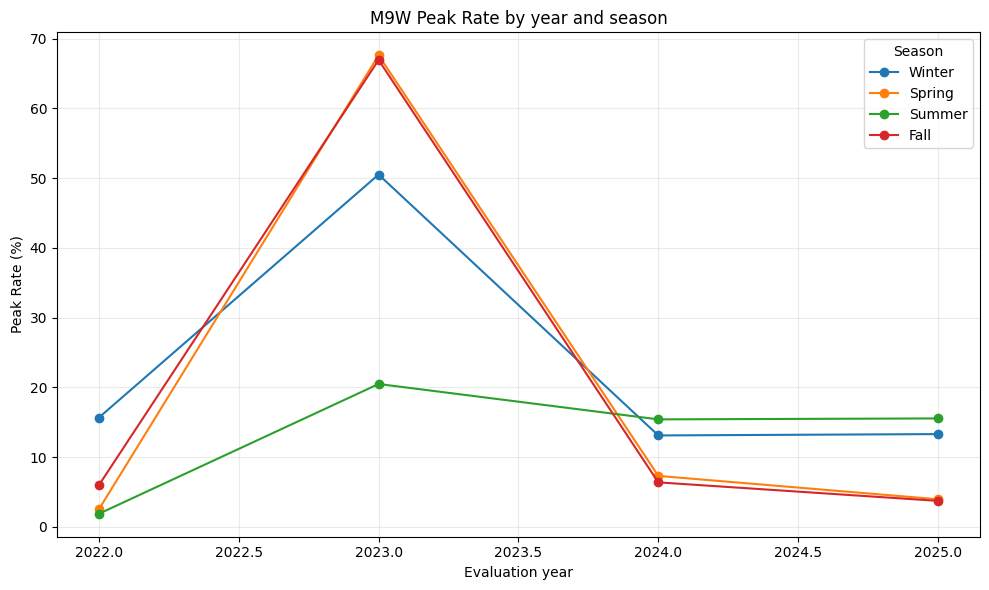

In [25]:
# Plot M9W Peak Rate by year and season
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall",
]

figure, axis = plt.subplots(
    figsize=(10, 6)
)

for season in season_order:
    subset = (
        m9w_peak_rate
        .loc[
            m9w_peak_rate["season"]
            == season
        ]
        .sort_values("year")
    )

    if subset.empty:
        continue

    axis.plot(
        subset["year"],
        subset["peak_rate_pct"],
        marker="o",
        label=season,
    )

axis.set_xlabel("Evaluation year")
axis.set_ylabel("Peak Rate (%)")

axis.set_title(
    "M9W Peak Rate by year and season"
)

axis.legend(
    title="Season"
)

axis.grid(
    alpha=0.25
)

figure.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
    / "07_03_m9w_peak_rate_by_year_season.png"
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [26]:
# Calculate annual electricity-demand statistics by FSA
consumption_fsa_year = (
    feature_dataset
    .groupby(
        ["fsa", "year"],
        observed=True,
    )["total_consumption_kwh"]
    .agg(
        observations="size",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)

quantiles = (
    feature_dataset
    .groupby(
        ["fsa", "year"],
        observed=True,
    )["total_consumption_kwh"]
    .quantile(
        [0.90, 0.95, 0.975, 0.99]
    )
    .unstack()
    .reset_index()
    .rename(
        columns={
            0.90: "p90",
            0.95: "p95",
            0.975: "p975",
            0.99: "p99",
        }
    )
)

consumption_fsa_year = (
    consumption_fsa_year
    .merge(
        quantiles,
        on=["fsa", "year"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        ["fsa", "year"]
    )
    .reset_index(drop=True)
)

consumption_fsa_year

,fsa,year,observations,mean,median,minimum,maximum,p90,p95,p975,p99
0,L4T,2021,8760,11526.924395,11147.55,5965.4,25152.4,15623.93,18625.680,21135.8600,23165.724
1,L4T,2022,8760,11563.738105,11133.10,5864.4,26563.9,15771.75,17985.410,19878.0375,22368.310
2,L4T,2023,8760,11305.241039,10980.95,5996.9,25114.0,15225.97,17278.010,19346.9850,21323.751
3,L4T,2024,8784,11630.045526,11149.40,5900.0,24923.6,16093.96,18638.705,20743.9500,22432.640
4,L4T,2025,8760,12063.893607,11498.25,6207.8,27796.6,16423.41,20188.845,22983.7200,25370.278
5,M5R,2021,8760,7560.686895,7387.00,3721.5,14104.9,10348.48,11243.320,11975.6050,12661.745
6,M5R,2022,8760,7677.844589,7499.05,3757.5,14325.6,10408.43,11208.700,11923.9150,12677.622
7,M5R,2023,8760,7449.867614,7366.45,3859.6,14484.0,9729.59,10438.305,11156.2625,12049.455
8,M5R,2024,8784,7506.734051,7319.85,3844.9,14839.2,10065.57,10807.170,11477.0675,12485.291
9,M5R,2025,8760,8115.475457,7835.90,3877.4,16999.0,11397.81,12293.185,13190.8100,14188.796


In [27]:
# Inspect annual electricity-demand statistics for M9W
m9w_consumption_year = (
    consumption_fsa_year
    .query("fsa == 'M9W'")
    .copy()
)

m9w_consumption_year

,fsa,year,observations,mean,median,minimum,maximum,p90,p95,p975,p99
25,M9W,2021,8760,8875.761450,8402.00,4361.1,21322.0,12335.71,14712.605,16744.4500,18915.802
26,M9W,2022,8760,9092.992454,8549.10,4433.6,22687.3,13155.38,15074.395,16460.3600,18311.835
27,M9W,2023,8760,14256.490411,14281.15,7954.4,29812.2,18067.11,20157.190,22169.3475,24930.831
28,M9W,2024,8784,14504.231683,14333.05,7964.7,30178.2,18814.58,21479.470,23435.3125,25794.622
29,M9W,2025,8760,14951.653642,14509.30,7887.9,33712.2,19171.92,22773.570,26601.0125,29371.753


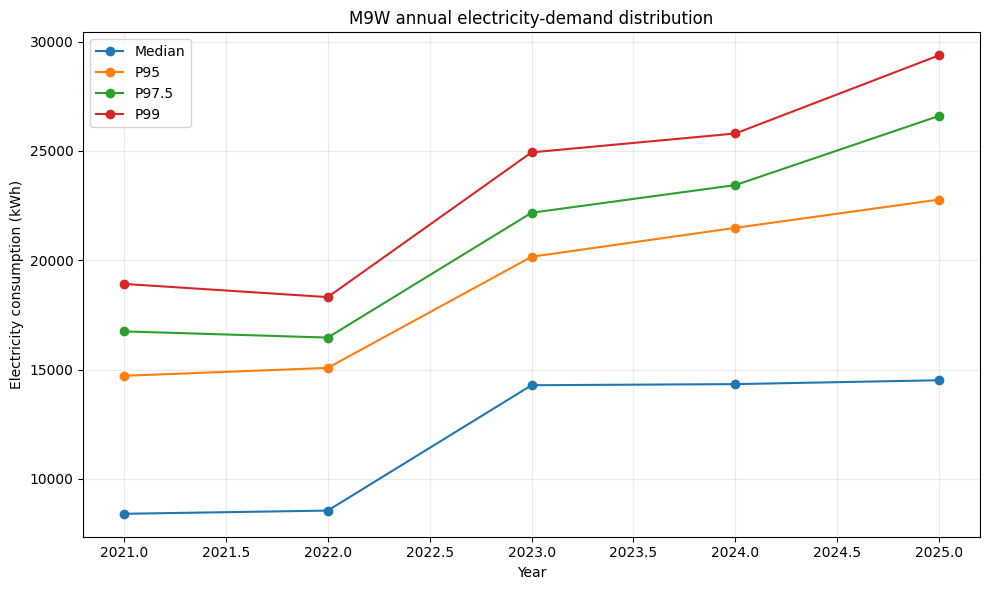

In [28]:
# Plot annual M9W demand distribution statistics
figure, axis = plt.subplots(
    figsize=(10, 6)
)

metrics = [
    ("median", "Median"),
    ("p95", "P95"),
    ("p975", "P97.5"),
    ("p99", "P99"),
]

for column, label in metrics:
    axis.plot(
        m9w_consumption_year["year"],
        m9w_consumption_year[column],
        marker="o",
        label=label,
    )

axis.set_xlabel("Year")
axis.set_ylabel(
    "Electricity consumption (kWh)"
)

axis.set_title(
    "M9W annual electricity-demand distribution"
)

axis.legend()

axis.grid(
    alpha=0.25
)

figure.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
    / "07_03_m9w_annual_demand_distribution.png"
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

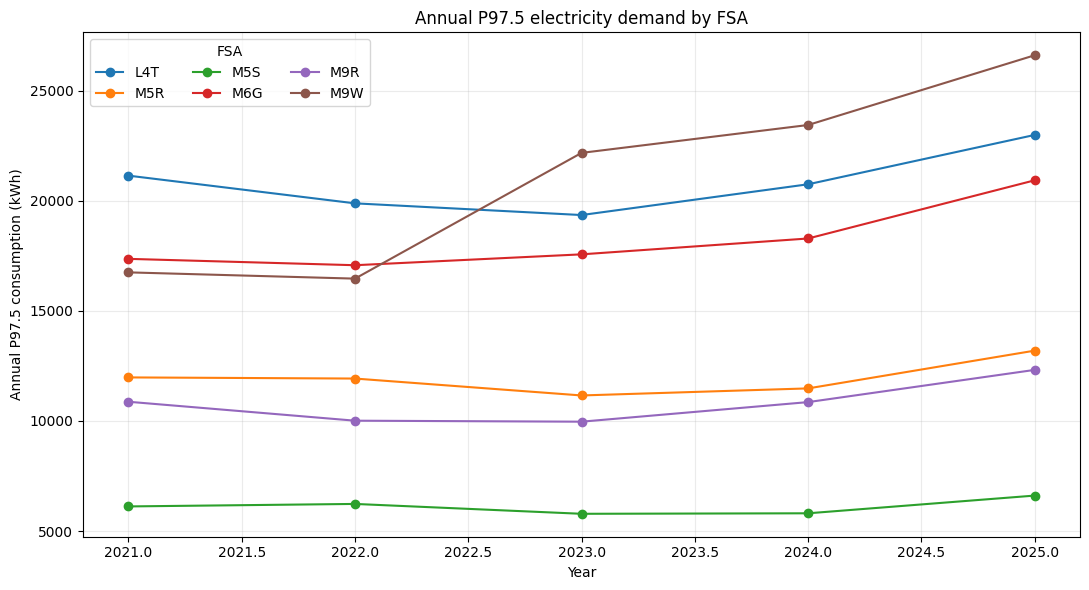

In [29]:
# Plot annual P97.5 electricity demand by FSA
figure, axis = plt.subplots(
    figsize=(11, 6)
)

for fsa, group in consumption_fsa_year.groupby(
    "fsa",
    observed=True,
):
    group = group.sort_values("year")

    axis.plot(
        group["year"],
        group["p975"],
        marker="o",
        label=str(fsa),
    )

axis.set_xlabel("Year")
axis.set_ylabel(
    "Annual P97.5 consumption (kWh)"
)

axis.set_title(
    "Annual P97.5 electricity demand by FSA"
)

axis.legend(
    title="FSA",
    ncol=3,
)

axis.grid(
    alpha=0.25
)

figure.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
    / "07_03_annual_p975_by_fsa.png"
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [30]:
# Verify whether premise-count information is available
"reported_premise_count" in feature_dataset.columns

True

In [31]:
# Summarize reported premise count by FSA and year
premise_fsa_year = (
    feature_dataset
    .groupby(
        ["fsa", "year"],
        observed=True,
    )["reported_premise_count"]
    .agg(
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
    .sort_values(
        ["fsa", "year"]
    )
    .reset_index(drop=True)
)

premise_fsa_year

,fsa,year,mean,median,minimum,maximum
0,L4T,2021,8640.013927,8641.0,8457,8653
1,L4T,2022,8616.039041,8614.0,8451,8632
2,L4T,2023,8587.590868,8591.0,8447,8604
3,L4T,2024,8566.142077,8580.0,8428,8600
4,L4T,2025,8564.553995,8571.0,8472,8579
5,M5R,2021,9308.172603,9308.0,9284,9324
6,M5R,2022,9331.796575,9328.0,9315,9406
7,M5R,2023,9391.759703,9383.0,9362,9427
8,M5R,2024,9381.943534,9393.0,8951,9421
9,M5R,2025,9454.27774,9414.0,8695,9984


In [32]:
# Inspect annual premise-count statistics for M9W
m9w_premise_year = (
    premise_fsa_year
    .query("fsa == 'M9W'")
    .copy()
)

m9w_premise_year

,fsa,year,mean,median,minimum,maximum
25,M9W,2021,9319.009018,9323.0,9157,9345
26,M9W,2022,9476.428881,9429.0,9172,10676
27,M9W,2023,11240.162671,11245.0,10678,11276
28,M9W,2024,11172.234631,11193.0,10900,11291
29,M9W,2025,11211.357648,11216.0,11058,11250


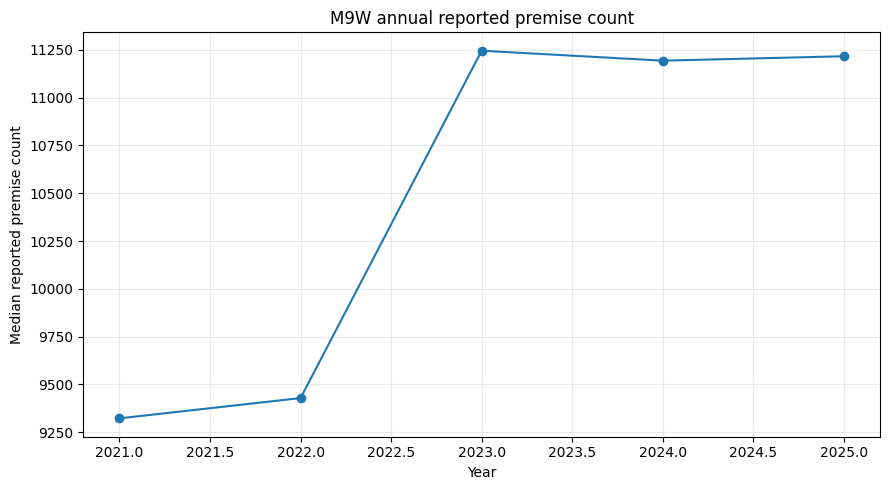

In [33]:
# Plot annual reported premise count for M9W
figure, axis = plt.subplots(
    figsize=(9, 5)
)

axis.plot(
    m9w_premise_year["year"],
    m9w_premise_year["median"],
    marker="o",
)

axis.set_xlabel("Year")
axis.set_ylabel(
    "Median reported premise count"
)

axis.set_title(
    "M9W annual reported premise count"
)

axis.grid(
    alpha=0.25
)

figure.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
    / "07_03_m9w_premise_count_by_year.png"
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [34]:
# Inspect threshold evolution
peak_thresholds.sort_values(
    [
        "fsa",
        "season",
        "evaluation_year",
    ]
).head(30)

,fsa,season,peak_threshold_kwh,evaluation_year,training_year_start,training_year_end
0,L4T,Fall,14434.4425,2022,2021,2021
24,L4T,Fall,15170.3775,2023,2021,2022
48,L4T,Fall,15910.4450,2024,2021,2023
72,L4T,Fall,16401.8625,2025,2021,2024
1,L4T,Spring,14997.0125,2022,2021,2021
25,L4T,Spring,15154.1750,2023,2021,2022
49,L4T,Spring,14726.1850,2024,2021,2023
73,L4T,Spring,14691.6675,2025,2021,2024
2,L4T,Summer,23769.5000,2022,2021,2021
26,L4T,Summer,23617.4750,2023,2021,2022


In [35]:
# Inspect M9W walk-forward Peak thresholds
m9w_thresholds = (
    peak_thresholds
    .query("fsa == 'M9W'")
    .sort_values(
        [
            "season",
            "evaluation_year",
        ]
    )
)

m9w_thresholds

,fsa,season,peak_threshold_kwh,evaluation_year,training_year_start,training_year_end
20,M9W,Fall,11302.6975,2022,2021,2021
44,M9W,Fall,11865.2675,2023,2021,2022
68,M9W,Fall,17276.6325,2024,2021,2023
92,M9W,Fall,17878.2125,2025,2021,2024
21,M9W,Spring,12038.6025,2022,2021,2021
45,M9W,Spring,12037.4625,2023,2021,2022
69,M9W,Spring,16582.4275,2024,2021,2023
93,M9W,Spring,16904.0700,2025,2021,2024
22,M9W,Summer,19435.6000,2022,2021,2021
46,M9W,Summer,19306.4125,2023,2021,2022


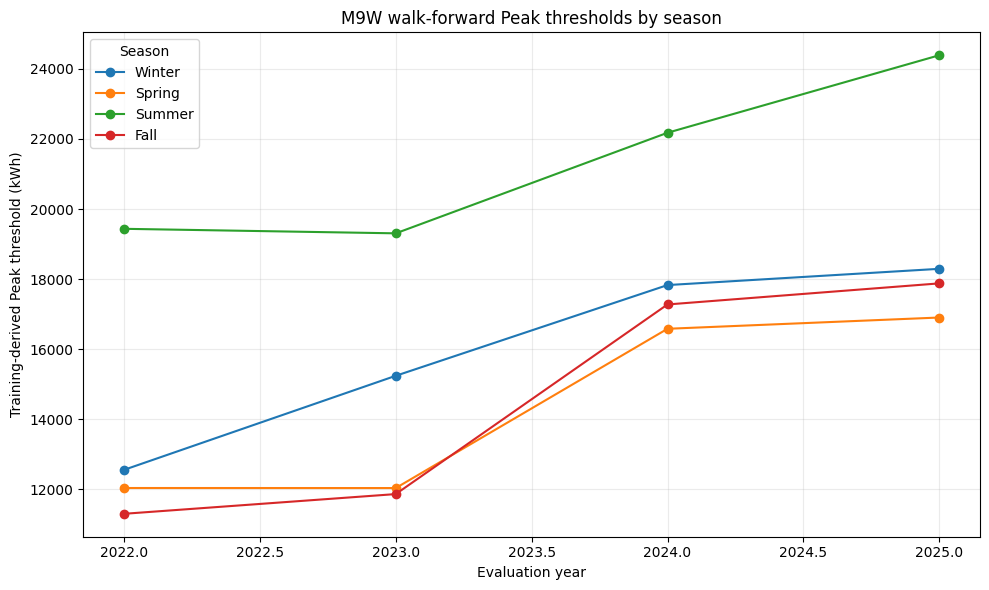

In [36]:
# Plot M9W walk-forward Peak thresholds by season
figure, axis = plt.subplots(
    figsize=(10, 6)
)

for season in season_order:
    subset = (
        m9w_thresholds
        .loc[
            m9w_thresholds["season"]
            == season
        ]
        .sort_values("evaluation_year")
    )

    if subset.empty:
        continue

    axis.plot(
        subset["evaluation_year"],
        subset["peak_threshold_kwh"],
        marker="o",
        label=season,
    )

axis.set_xlabel("Evaluation year")

axis.set_ylabel(
    "Training-derived Peak threshold (kWh)"
)

axis.set_title(
    "M9W walk-forward Peak thresholds by season"
)

axis.legend(
    title="Season"
)

axis.grid(
    alpha=0.25
)

figure.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
    / "07_03_m9w_peak_threshold_evolution.png"
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [37]:
# Save additional Target Definition diagnostic reports
additional_reports = {
    "07_03_peak_rate_by_fsa_year.csv":
        peak_rate_fsa_year,

    "07_03_peak_rate_by_fsa_year_season.csv":
        peak_rate_fsa_year_season,

    "07_03_consumption_statistics_by_fsa_year.csv":
        consumption_fsa_year,
}

if (
    "reported_premise_count"
    in feature_dataset.columns
):
    additional_reports[
        "07_03_premise_count_by_fsa_year.csv"
    ] = premise_fsa_year

for filename, dataframe in additional_reports.items():

    output_path = (
        REPORTS_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"Saved: {output_path}"
    )

Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\target_definition\07_03_peak_rate_by_fsa_year.csv
Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\target_definition\07_03_peak_rate_by_fsa_year_season.csv
Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\target_definition\07_03_consumption_statistics_by_fsa_year.csv
Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\target_definition\07_03_premise_count_by_fsa_year.csv


## Review M9W to analize changes in 2023

In [39]:
# Define the diagnostic period around the M9W structural change
TRANSITION_START = pd.Timestamp("2022-07-01")
TRANSITION_END = pd.Timestamp("2023-06-30 23:00:00")

m9w_transition = (
    feature_dataset.loc[
        (feature_dataset["fsa"] == "M9W")
        & (
            feature_dataset["timestamp"]
            >= TRANSITION_START
        )
        & (
            feature_dataset["timestamp"]
            <= TRANSITION_END
        )
    ]
    .copy()
    .sort_values("timestamp")
)

print(
    f"Transition-period observations: "
    f"{len(m9w_transition):,}"
)

print(
    f"Period: "
    f"{m9w_transition['timestamp'].min()} "
    f"to "
    f"{m9w_transition['timestamp'].max()}"
)

m9w_transition[
    [
        "fsa",
        "timestamp",
        "total_consumption_kwh",
        "reported_premise_count",
    ]
].head()

Transition-period observations: 8,760
Period: 2022-07-01 00:00:00 to 2023-06-30 23:00:00


,fsa,timestamp,total_consumption_kwh,reported_premise_count
232224,M9W,2022-07-01 00:00:00,8803.7,9420
232225,M9W,2022-07-01 01:00:00,7774.0,9420
232226,M9W,2022-07-01 02:00:00,7071.3,9420
232227,M9W,2022-07-01 03:00:00,6728.8,9420
232228,M9W,2022-07-01 04:00:00,6523.8,9420


In [40]:
# Create daily M9W statistics for the transition period
m9w_transition["diagnostic_date"] = (
    m9w_transition["timestamp"]
    .dt.floor("D")
)

daily_consumption = (
    m9w_transition
    .groupby(
        "diagnostic_date",
        observed=True,
    )["total_consumption_kwh"]
    .agg(
        mean_consumption_kwh="mean",
        median_consumption_kwh="median",
        minimum_consumption_kwh="min",
        maximum_consumption_kwh="max",
    )
    .reset_index()
)

daily_p95 = (
    m9w_transition
    .groupby(
        "diagnostic_date",
        observed=True,
    )["total_consumption_kwh"]
    .quantile(0.95)
    .rename("p95_consumption_kwh")
    .reset_index()
)

daily_premises = (
    m9w_transition
    .groupby(
        "diagnostic_date",
        observed=True,
    )["reported_premise_count"]
    .agg(
        median_premise_count="median",
        minimum_premise_count="min",
        maximum_premise_count="max",
    )
    .reset_index()
)

m9w_daily_transition = (
    daily_consumption
    .merge(
        daily_p95,
        on="diagnostic_date",
        how="left",
        validate="one_to_one",
    )
    .merge(
        daily_premises,
        on="diagnostic_date",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "diagnostic_date"
    )
    .reset_index(drop=True)
)

m9w_daily_transition.head(20)

,diagnostic_date,mean_consumption_kwh,median_consumption_kwh,minimum_consumption_kwh,maximum_consumption_kwh,p95_consumption_kwh,median_premise_count,minimum_premise_count,maximum_premise_count
0,2022-07-01,10869.400000,11559.30,6523.8,14325.8,14122.450,9420.0,9420,9420
1,2022-07-02,10776.966667,11492.70,5795.0,14925.8,14859.515,9420.0,9420,9420
2,2022-07-03,10436.816667,10926.95,5392.3,15176.2,14969.620,9420.0,9420,9420
3,2022-07-04,9724.987500,10224.45,5760.0,13003.0,12911.290,9422.0,9420,9422
4,2022-07-05,9175.983333,8547.90,6159.8,13495.4,13394.630,9422.0,9422,9422
5,2022-07-06,8726.020833,8454.95,5800.4,12113.4,11925.030,9422.0,9422,9422
6,2022-07-07,9724.758333,9610.70,5323.7,14307.7,14241.920,9421.0,9421,9422
7,2022-07-08,10202.304167,10294.90,6144.2,14233.6,14005.080,9421.0,9421,9421
8,2022-07-09,9351.354167,9955.30,5369.6,12864.7,12663.520,9420.5,9420,9421
9,2022-07-10,10612.033333,11400.25,5189.1,15668.2,15439.150,9421.0,9421,9421


In [41]:
# Create a monthly summary to make the structural transition easier to inspect
m9w_daily_transition["month"] = (
    m9w_daily_transition[
        "diagnostic_date"
    ]
    .dt.to_period("M")
    .astype(str)
)

m9w_monthly_transition = (
    m9w_daily_transition
    .groupby(
        "month",
        observed=True,
    )
    .agg(
        days=(
            "diagnostic_date",
            "size",
        ),
        mean_daily_consumption_kwh=(
            "mean_consumption_kwh",
            "mean",
        ),
        median_daily_consumption_kwh=(
            "median_consumption_kwh",
            "median",
        ),
        mean_daily_p95_kwh=(
            "p95_consumption_kwh",
            "mean",
        ),
        median_premise_count=(
            "median_premise_count",
            "median",
        ),
    )
    .reset_index()
)

m9w_monthly_transition

,month,days,mean_daily_consumption_kwh,median_daily_consumption_kwh,mean_daily_p95_kwh,median_premise_count
0,2022-07,31,11268.688306,11120.700,15388.656290,9424.0
1,2022-08,31,10976.257258,10833.150,15039.284194,9429.0
2,2022-09,30,8234.003056,8184.775,11234.855667,9430.0
3,2022-10,31,7213.266398,7130.150,9522.357581,9429.0
4,2022-11,30,7893.166528,7875.450,10455.274000,9430.0
5,2022-12,31,11347.787634,12791.950,14132.239355,10674.0
6,2023-01,31,14672.657124,15534.300,17541.145323,11216.0
7,2023-02,28,14938.385119,15601.350,17559.187500,11270.0
8,2023-03,31,14367.104032,15317.600,16710.263065,11272.0
9,2023-04,30,13032.659444,13890.800,15349.525500,11273.0


In [42]:
# Calculate month-over-month changes
m9w_monthly_transition[
    "consumption_mom_pct"
] = (
    m9w_monthly_transition[
        "median_daily_consumption_kwh"
    ]
    .pct_change()
    * 100
)

m9w_monthly_transition[
    "premise_count_mom_pct"
] = (
    m9w_monthly_transition[
        "median_premise_count"
    ]
    .pct_change()
    * 100
)

m9w_monthly_transition

,month,days,mean_daily_consumption_kwh,median_daily_consumption_kwh,mean_daily_p95_kwh,median_premise_count,consumption_mom_pct,premise_count_mom_pct
0,2022-07,31,11268.688306,11120.700,15388.656290,9424.0,NaN,<NA>
1,2022-08,31,10976.257258,10833.150,15039.284194,9429.0,-2.585719,0.053056
2,2022-09,30,8234.003056,8184.775,11234.855667,9430.0,-24.446952,0.010606
3,2022-10,31,7213.266398,7130.150,9522.357581,9429.0,-12.885205,-0.010604
4,2022-11,30,7893.166528,7875.450,10455.274000,9430.0,10.452796,0.010606
5,2022-12,31,11347.787634,12791.950,14132.239355,10674.0,62.428179,13.191941
6,2023-01,31,14672.657124,15534.300,17541.145323,11216.0,21.438092,5.077759
7,2023-02,28,14938.385119,15601.350,17559.187500,11270.0,0.431625,0.481455
8,2023-03,31,14367.104032,15317.600,16710.263065,11272.0,-1.818753,0.017746
9,2023-04,30,13032.659444,13890.800,15349.525500,11273.0,-9.314775,0.008872


In [43]:
# Identify the largest month-to-month changes
largest_consumption_changes = (
    m9w_monthly_transition[
        [
            "month",
            "median_daily_consumption_kwh",
            "consumption_mom_pct",
        ]
    ]
    .sort_values(
        "consumption_mom_pct",
        ascending=False,
    )
)

largest_premise_changes = (
    m9w_monthly_transition[
        [
            "month",
            "median_premise_count",
            "premise_count_mom_pct",
        ]
    ]
    .sort_values(
        "premise_count_mom_pct",
        ascending=False,
    )
)

print(
    "Largest monthly consumption changes:"
)

display(
    largest_consumption_changes.head(6)
)

print(
    "\nLargest monthly premise-count changes:"
)

display(
    largest_premise_changes.head(6)
)

Largest monthly consumption changes:


,month,median_daily_consumption_kwh,consumption_mom_pct
5,2022-12,12791.950,62.428179
6,2023-01,15534.300,21.438092
4,2022-11,7875.450,10.452796
11,2023-06,14475.375,10.005282
7,2023-02,15601.350,0.431625
8,2023-03,15317.600,-1.818753



Largest monthly premise-count changes:


,month,median_premise_count,premise_count_mom_pct
5,2022-12,10674.0,13.191941
6,2023-01,11216.0,5.077759
7,2023-02,11270.0,0.481455
1,2022-08,9429.0,0.053056
8,2023-03,11272.0,0.017746
4,2022-11,9430.0,0.010606


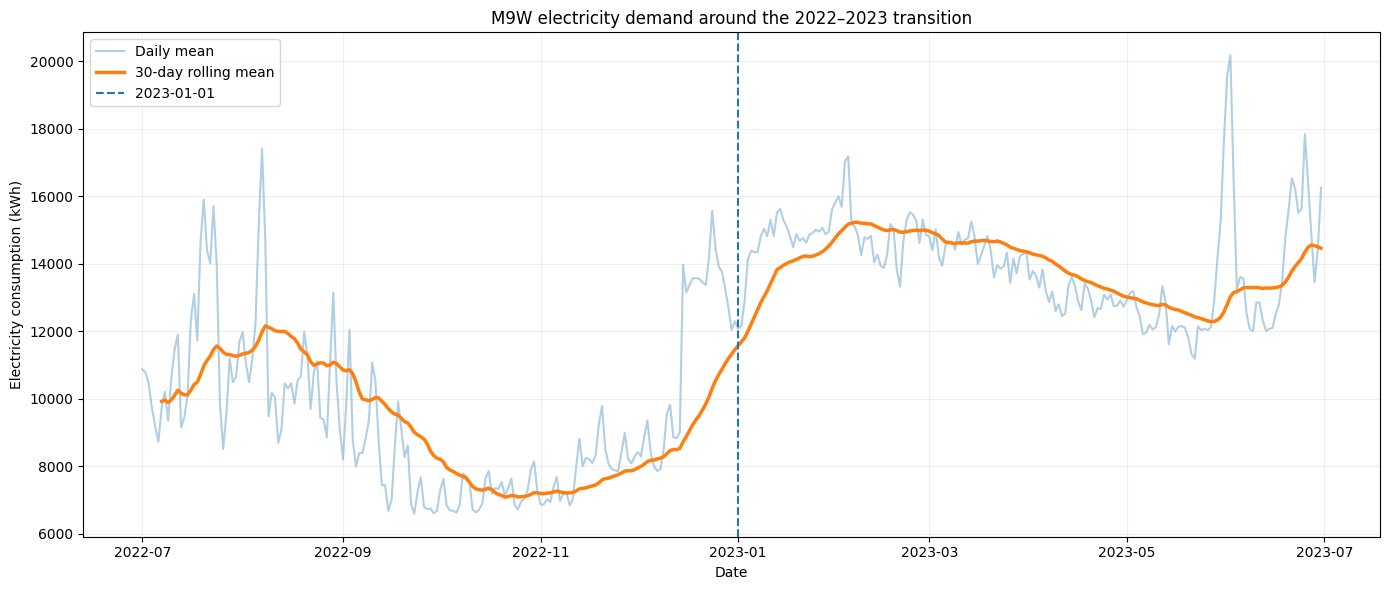

In [44]:
# Calculate a 30-day rolling mean for visualization only
m9w_daily_transition[
    "consumption_30d_mean"
] = (
    m9w_daily_transition[
        "mean_consumption_kwh"
    ]
    .rolling(
        window=30,
        min_periods=7,
    )
    .mean()
)

figure, axis = plt.subplots(
    figsize=(14, 6)
)

axis.plot(
    m9w_daily_transition[
        "diagnostic_date"
    ],
    m9w_daily_transition[
        "mean_consumption_kwh"
    ],
    alpha=0.35,
    label="Daily mean",
)

axis.plot(
    m9w_daily_transition[
        "diagnostic_date"
    ],
    m9w_daily_transition[
        "consumption_30d_mean"
    ],
    linewidth=2.5,
    label="30-day rolling mean",
)

axis.axvline(
    pd.Timestamp("2023-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="2023-01-01",
)

axis.set_xlabel("Date")

axis.set_ylabel(
    "Electricity consumption (kWh)"
)

axis.set_title(
    "M9W electricity demand around the 2022–2023 transition"
)

axis.legend()

axis.grid(
    alpha=0.20
)

figure.tight_layout()

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "07_03_m9w_transition_daily_consumption.png"
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

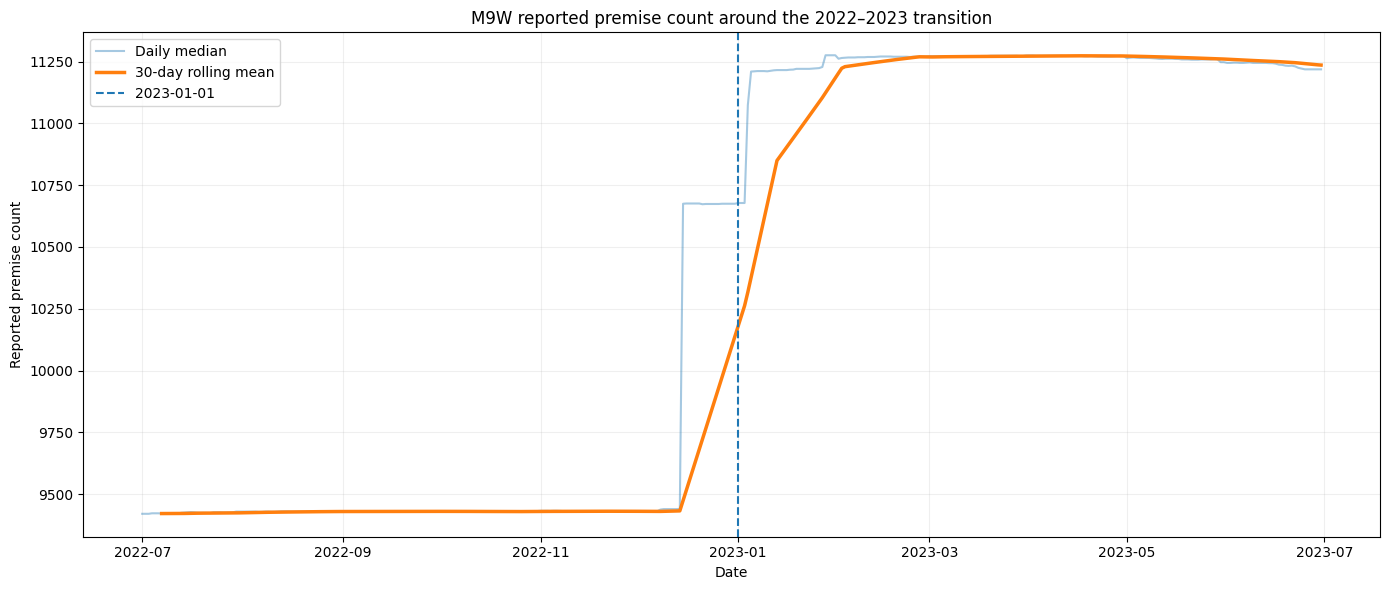

In [45]:
# Calculate a 30-day rolling mean of reported premise count
m9w_daily_transition[
    "premise_count_30d_mean"
] = (
    m9w_daily_transition[
        "median_premise_count"
    ]
    .rolling(
        window=30,
        min_periods=7,
    )
    .mean()
)

figure, axis = plt.subplots(
    figsize=(14, 6)
)

axis.plot(
    m9w_daily_transition[
        "diagnostic_date"
    ],
    m9w_daily_transition[
        "median_premise_count"
    ],
    alpha=0.40,
    label="Daily median",
)

axis.plot(
    m9w_daily_transition[
        "diagnostic_date"
    ],
    m9w_daily_transition[
        "premise_count_30d_mean"
    ],
    linewidth=2.5,
    label="30-day rolling mean",
)

axis.axvline(
    pd.Timestamp("2023-01-01"),
    linestyle="--",
    linewidth=1.5,
    label="2023-01-01",
)

axis.set_xlabel("Date")

axis.set_ylabel(
    "Reported premise count"
)

axis.set_title(
    "M9W reported premise count around the 2022–2023 transition"
)

axis.legend()

axis.grid(
    alpha=0.20
)

figure.tight_layout()

figure_path = (
    FIGURES_DIR
    / "07_03_m9w_transition_premise_count.png"
)

figure.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [46]:
# Identify the largest daily changes in reported premise count
premise_daily_changes = (
    m9w_daily_transition[
        [
            "diagnostic_date",
            "median_premise_count",
        ]
    ]
    .copy()
)

premise_daily_changes[
    "premise_count_change"
] = (
    premise_daily_changes[
        "median_premise_count"
    ]
    .diff()
)

premise_daily_changes[
    "premise_count_change_pct"
] = (
    premise_daily_changes[
        "median_premise_count"
    ]
    .pct_change()
    * 100
)

premise_daily_changes[
    "absolute_change"
] = (
    premise_daily_changes[
        "premise_count_change"
    ]
    .abs()
)

largest_daily_premise_changes = (
    premise_daily_changes
    .sort_values(
        "absolute_change",
        ascending=False,
    )
    .head(15)
)

largest_daily_premise_changes

,diagnostic_date,median_premise_count,premise_count_change,premise_count_change_pct,absolute_change
167,2022-12-15,10675.0,1235.0,13.082627,1235.0
187,2023-01-04,11074.0,396.0,3.70856,396.0
188,2023-01-05,11210.0,136.0,1.228102,136.0
211,2023-01-28,11276.0,47.5,0.423031,47.5
215,2023-02-01,11262.0,-14.0,-0.124158,14.0
333,2023-05-30,11248.0,-12.0,-0.106572,12.0
304,2023-05-01,11264.0,-9.0,-0.079837,9.0
160,2022-12-08,9437.0,7.0,0.074231,7.0
357,2023-06-23,11225.0,-6.0,-0.053424,6.0
210,2023-01-27,11228.5,4.5,0.040093,4.5


In [47]:
# Identify the largest changes in the 30-day consumption trend
consumption_trend_changes = (
    m9w_daily_transition[
        [
            "diagnostic_date",
            "consumption_30d_mean",
        ]
    ]
    .copy()
)

consumption_trend_changes[
    "rolling_mean_change"
] = (
    consumption_trend_changes[
        "consumption_30d_mean"
    ]
    .diff()
)

consumption_trend_changes[
    "absolute_change"
] = (
    consumption_trend_changes[
        "rolling_mean_change"
    ]
    .abs()
)

consumption_trend_changes = (
    consumption_trend_changes
    .sort_values(
        "absolute_change",
        ascending=False,
    )
)

consumption_trend_changes.head(15)

,diagnostic_date,consumption_30d_mean,rolling_mean_change,absolute_change
67,2022-09-06,10197.027500,-300.777361,300.777361
19,2022-07-20,10965.961667,259.735570,259.735570
176,2022-12-24,10305.710417,256.371806,256.371806
66,2022-09-05,10497.804861,-240.756111,240.756111
37,2022-08-07,11975.301111,240.036667,240.036667
336,2023-06-02,13017.609722,232.815833,232.815833
177,2022-12-25,10526.568472,220.858056,220.858056
18,2022-07-19,10706.226096,219.265217,219.265217
196,2023-01-13,13825.684167,217.220833,217.220833
189,2023-01-06,12418.912917,216.162361,216.162361


In [48]:
# Save the transition diagnostic table
transition_report_path = (
    REPORTS_DIR
    / "07_03_m9w_2022_2023_transition_monthly.csv"
)

m9w_monthly_transition.to_csv(
    transition_report_path,
    index=False,
    encoding="utf-8-sig",
)

print(
    f"Saved: {transition_report_path}"
)

Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\target_definition\07_03_m9w_2022_2023_transition_monthly.csv


In [49]:
premise_changes_path = (
    REPORTS_DIR
    / "07_03_m9w_largest_daily_premise_changes.csv"
)

largest_daily_premise_changes.to_csv(
    premise_changes_path,
    index=False,
    encoding="utf-8-sig",
)

print(
    f"Saved: {premise_changes_path}"
)

Saved: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\reports\target_definition\07_03_m9w_largest_daily_premise_changes.csv


## Display images

Generated figures: 9

07_03_annual_p975_by_fsa.png


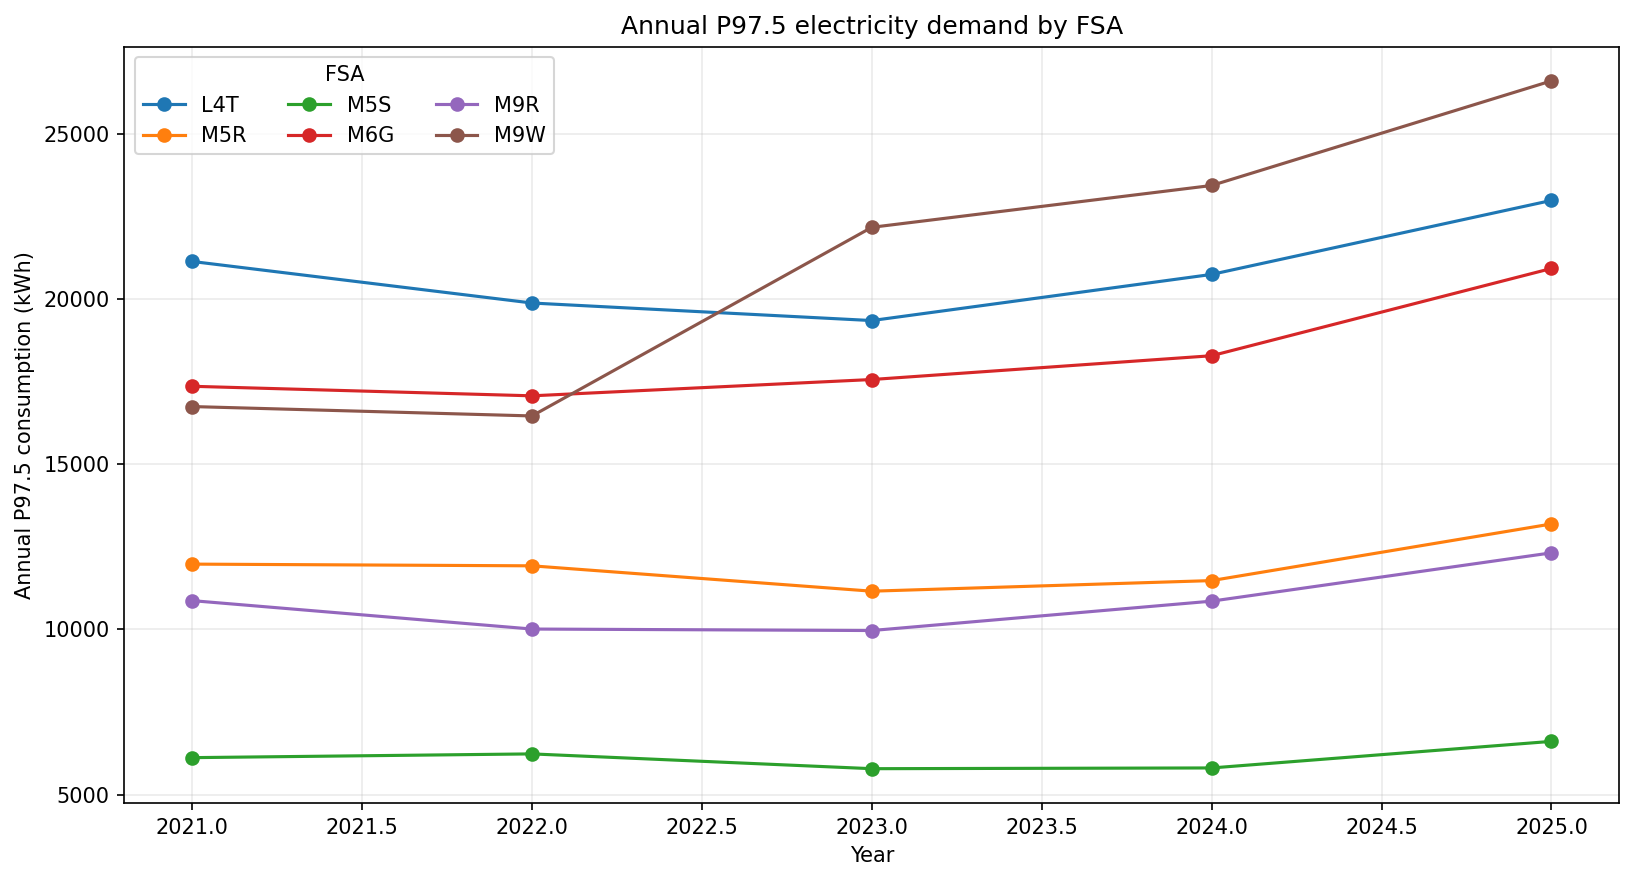


07_03_m9w_annual_demand_distribution.png


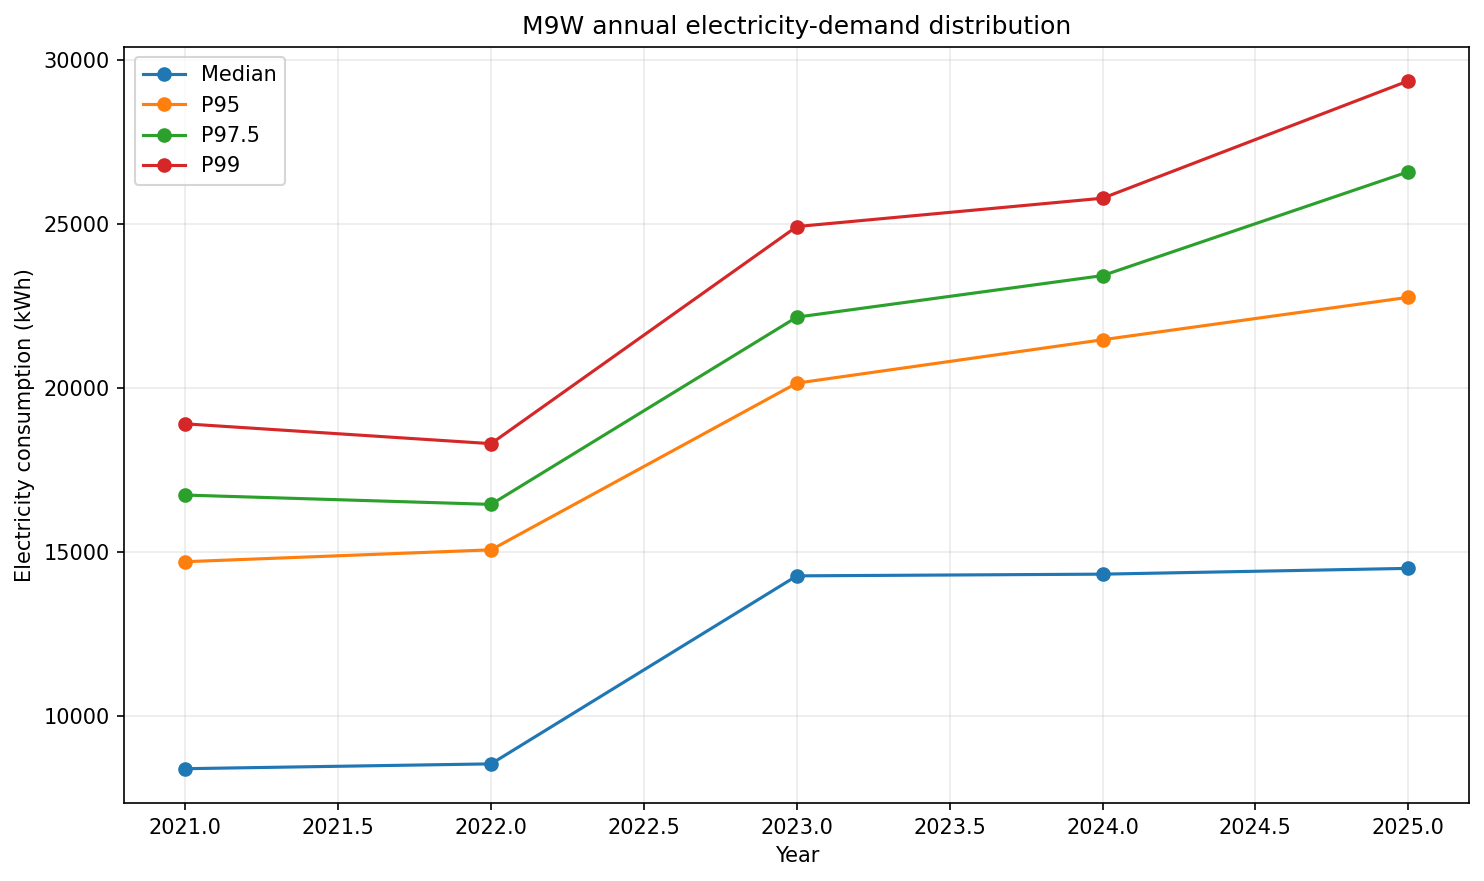


07_03_m9w_peak_rate_by_year_season.png


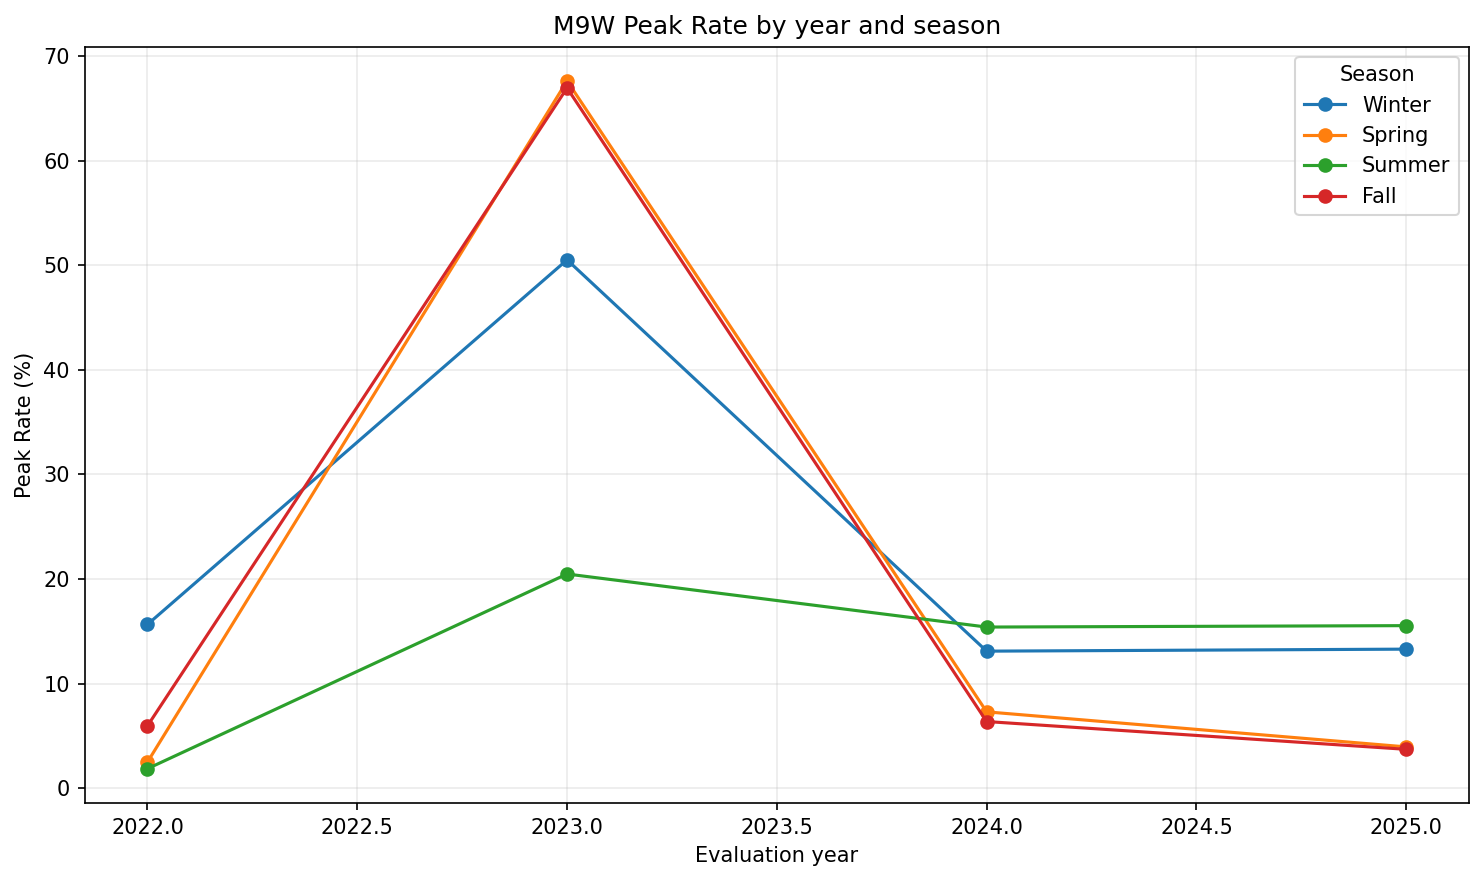


07_03_m9w_peak_threshold_evolution.png


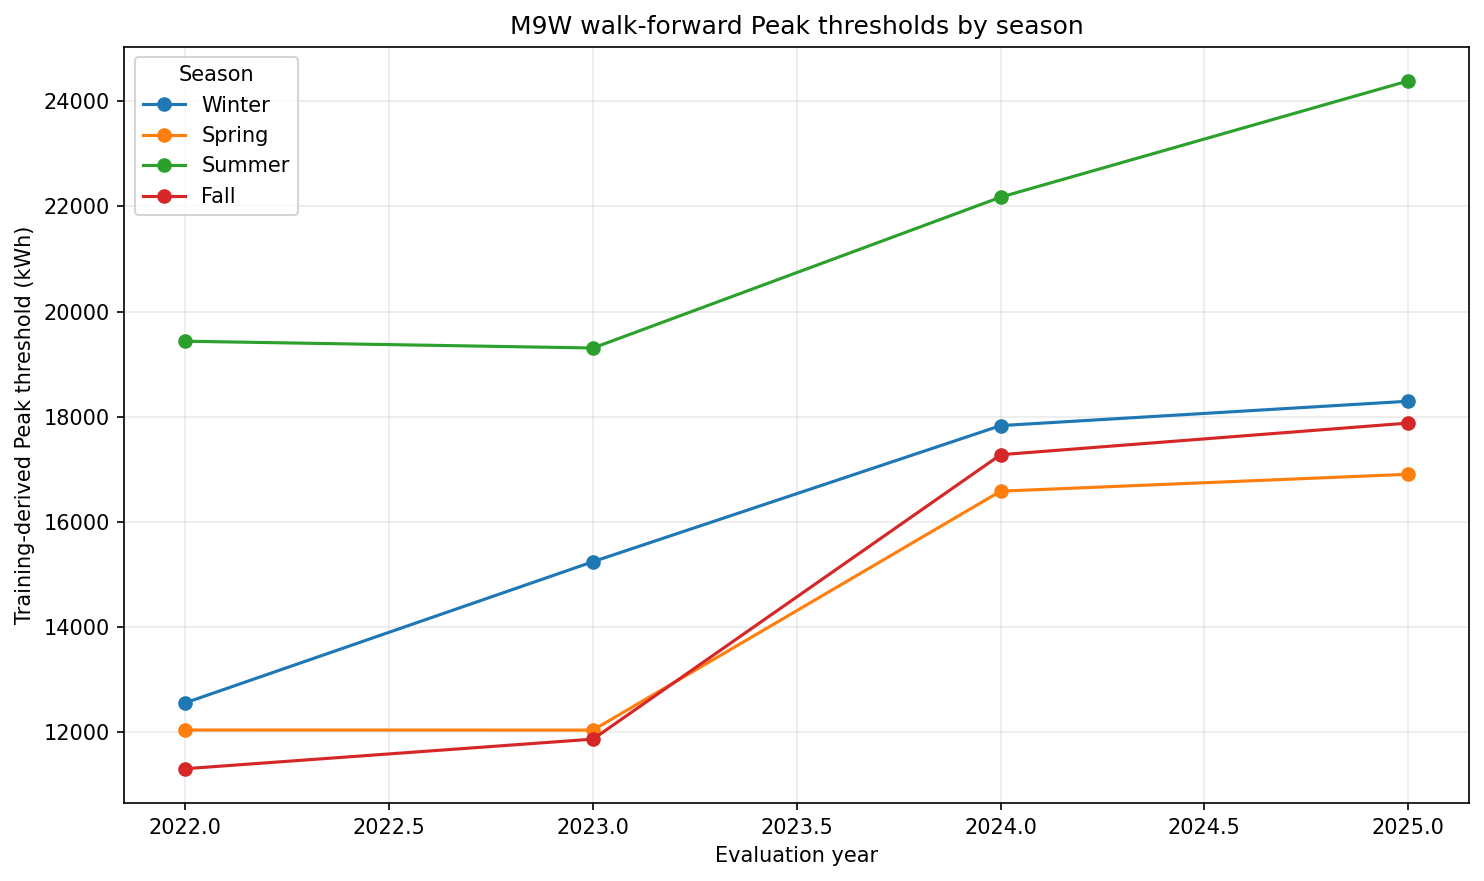


07_03_m9w_premise_count_by_year.png


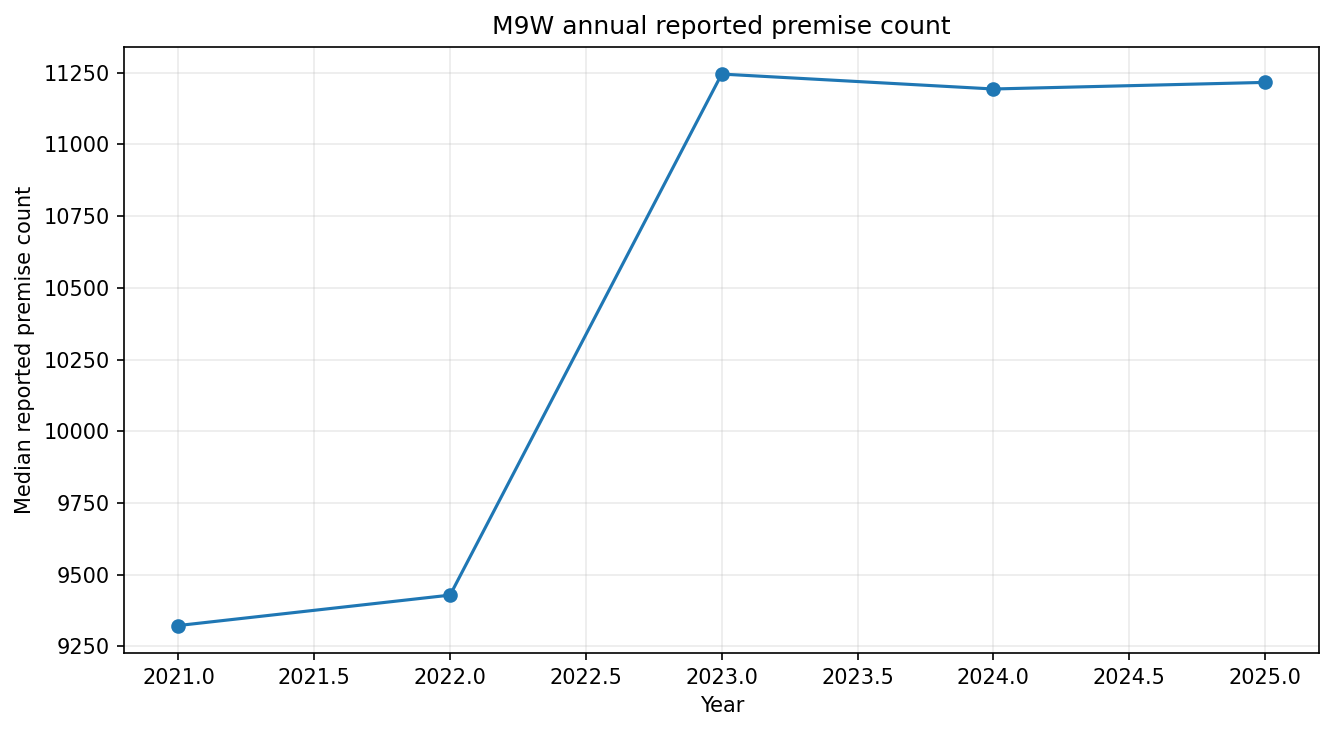


07_03_m9w_transition_daily_consumption.png


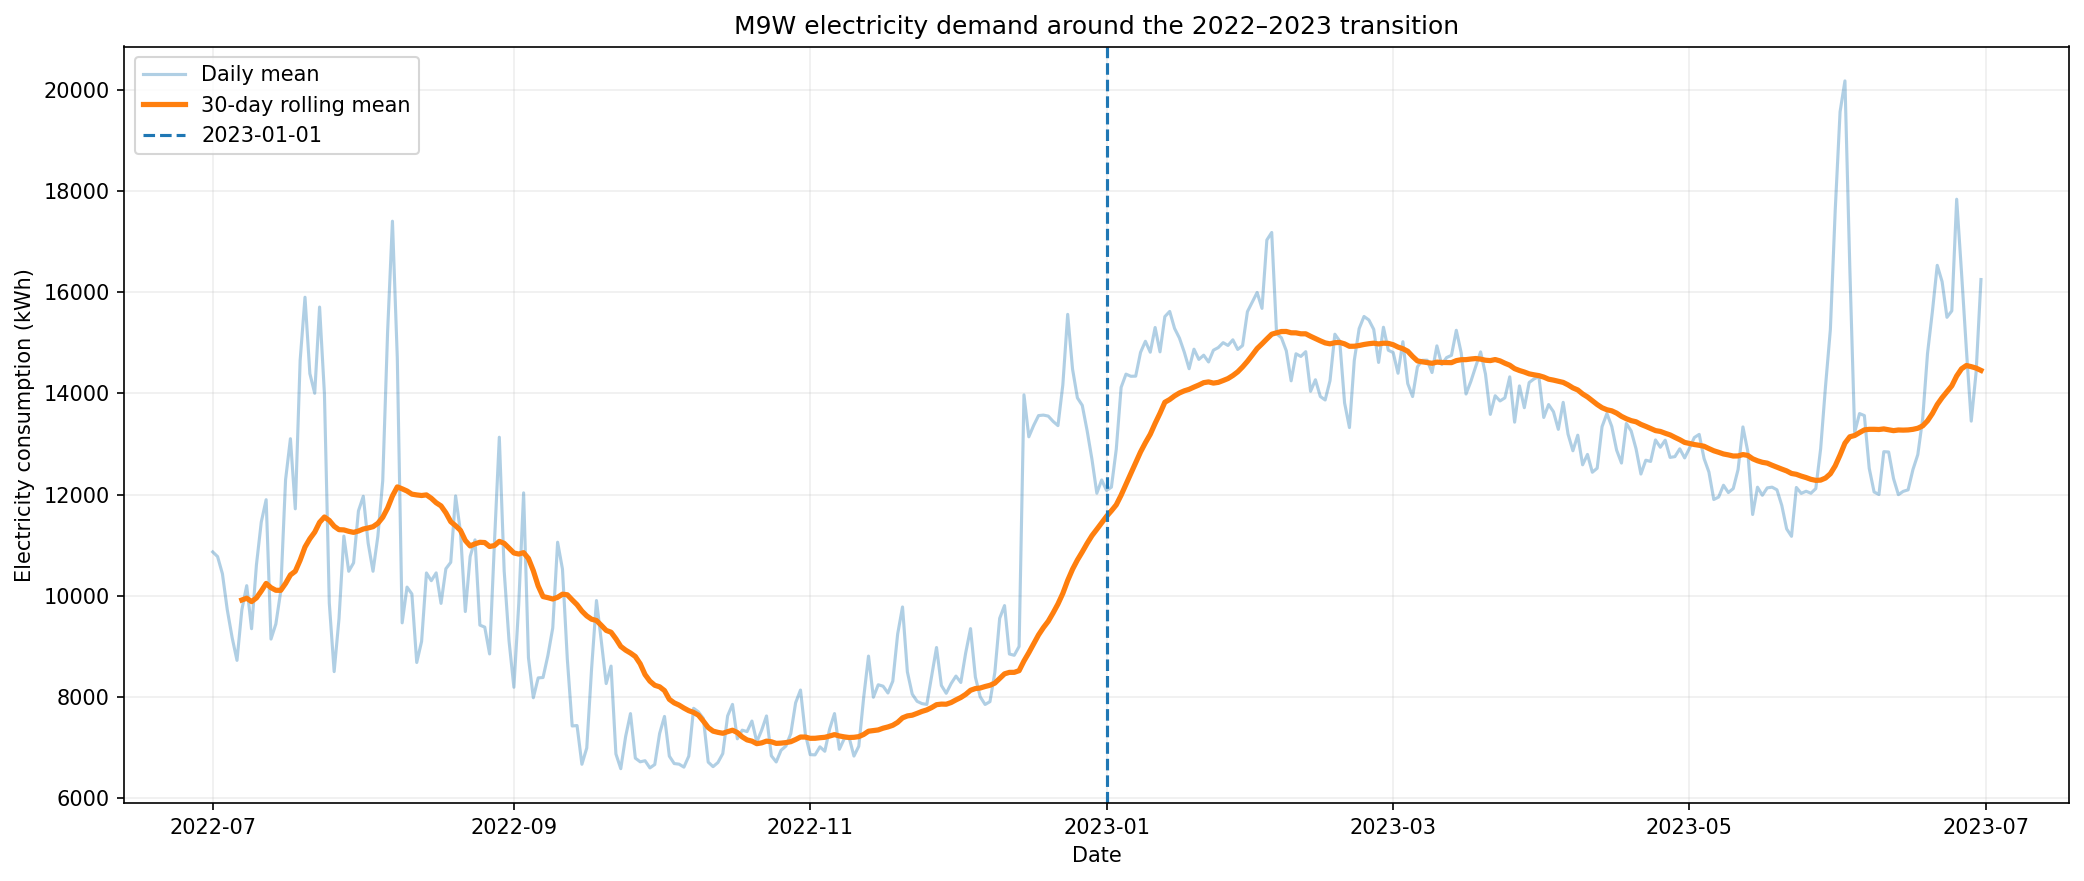


07_03_m9w_transition_premise_count.png


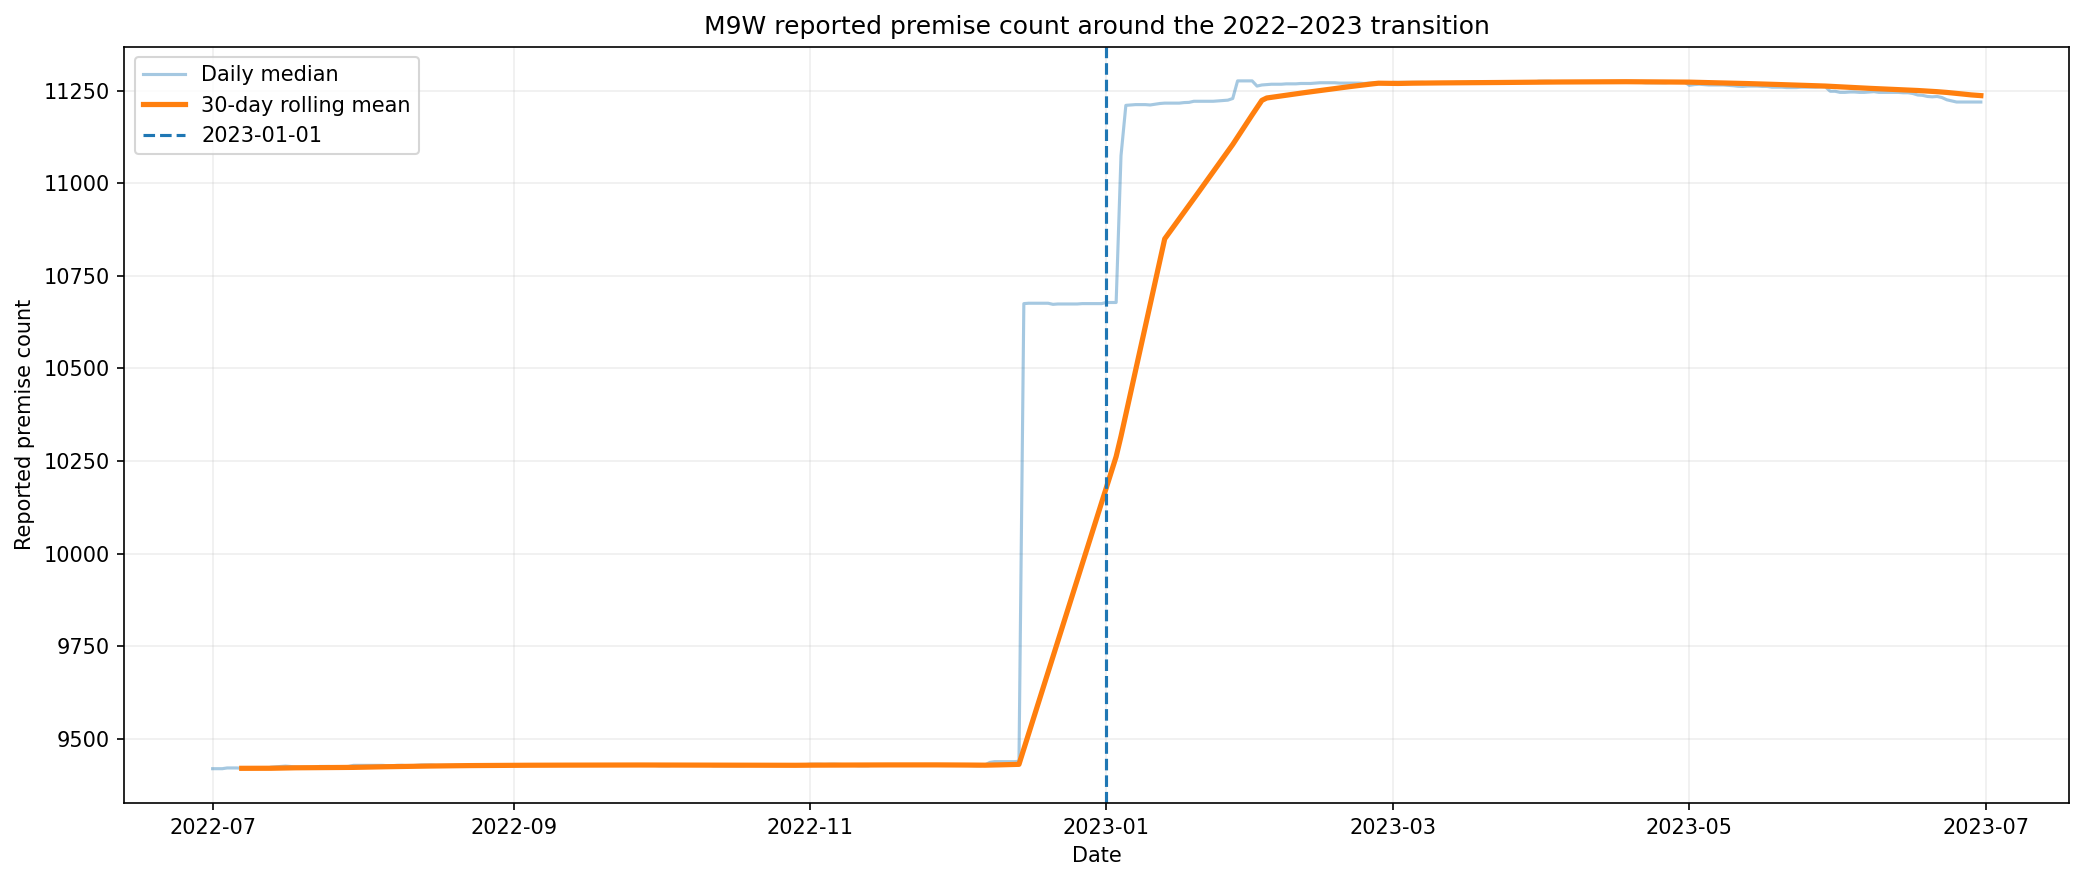


07_03_peak_rate_by_fsa_year.png


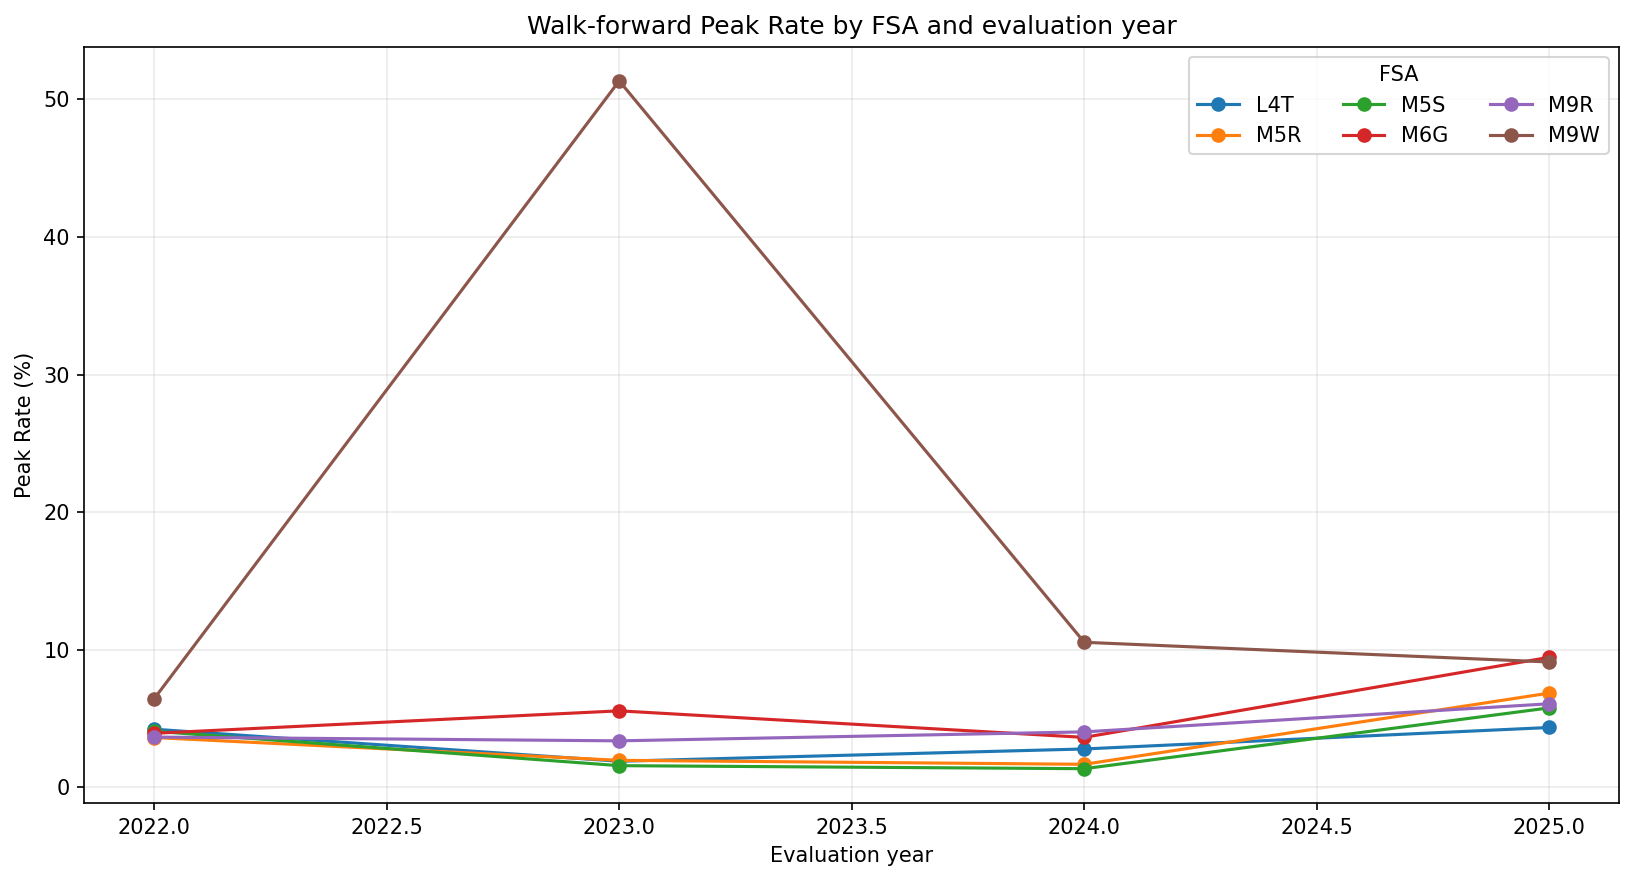


07_03_peak_rate_fsa_year_heatmap.png


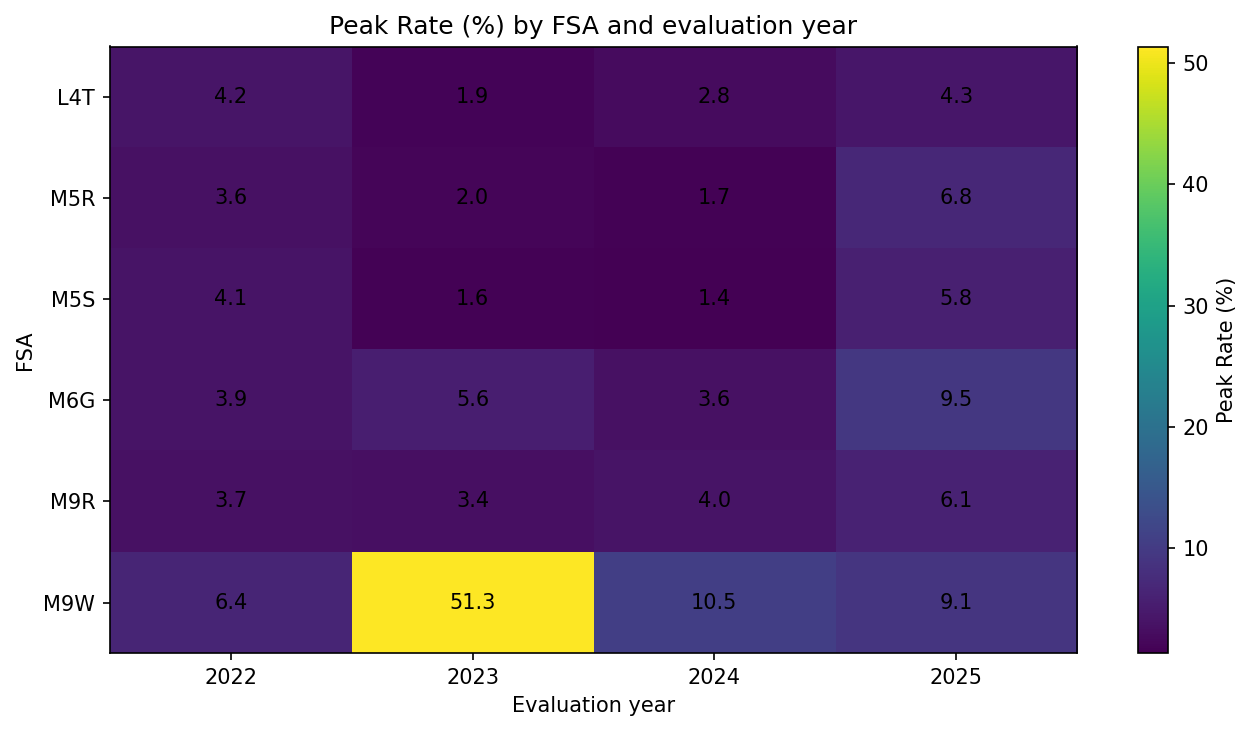

In [50]:
# Display all figures generated for the Target Distribution analysis
from IPython.display import Image, display

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "target_definition"
)

generated_figures = sorted(
    FIGURES_DIR.glob(
        "07_03_*.png"
    )
)

print(
    f"Generated figures: "
    f"{len(generated_figures)}"
)

for figure_path in generated_figures:

    print(
        f"\n{figure_path.name}"
    )

    display(
        Image(
            filename=str(
                figure_path
            )
        )
    )